In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import glob
import numpy as np
from matplotlib import colors as mcolors
import colorsys
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
import plotly.express as px
from scipy.spatial.distance import euclidean
from scipy.stats import zscore
import plotly.graph_objects as go

## 1000 genomes initial quality control

/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/4144589015.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  freqs = pd.read_csv('1_qc/freqs.frq', delim_whitespace=True)


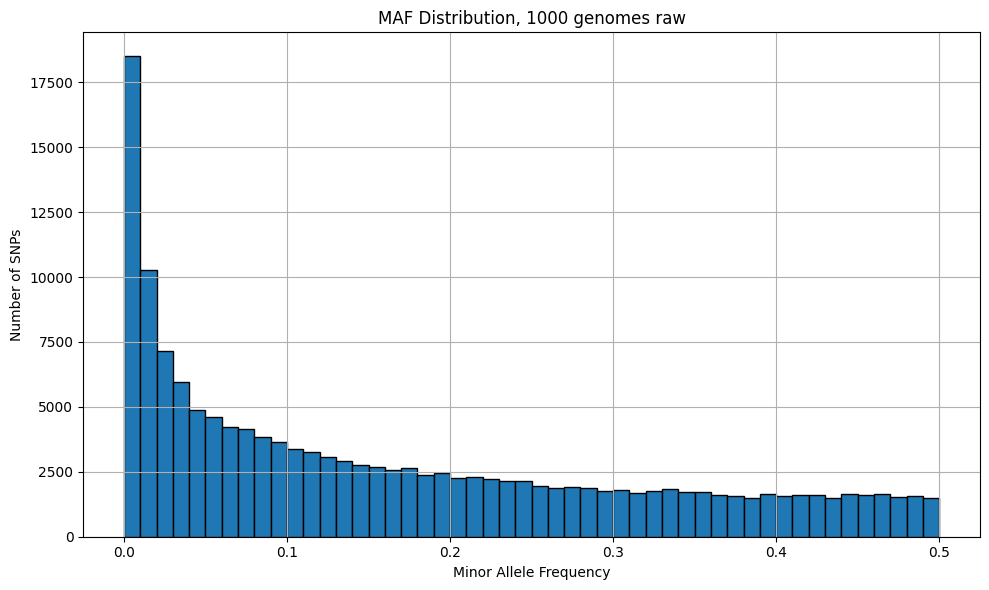

In [3]:
freqs = pd.read_csv('1_qc/freqs.frq', delim_whitespace=True)

plt.figure(figsize=(10, 6))
plt.hist(freqs['MAF'], bins=50, edgecolor='black')
plt.title('MAF Distribution, 1000 genomes raw')
plt.xlabel('Minor Allele Frequency')
plt.ylabel('Number of SNPs')
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/2426864923.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  imiss = pd.read_csv('1_qc/missingness.imiss', delim_whitespace=True)
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/2426864923.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  lmiss = pd.read_csv('1_qc/missingness.lmiss', delim_whitespace=True)


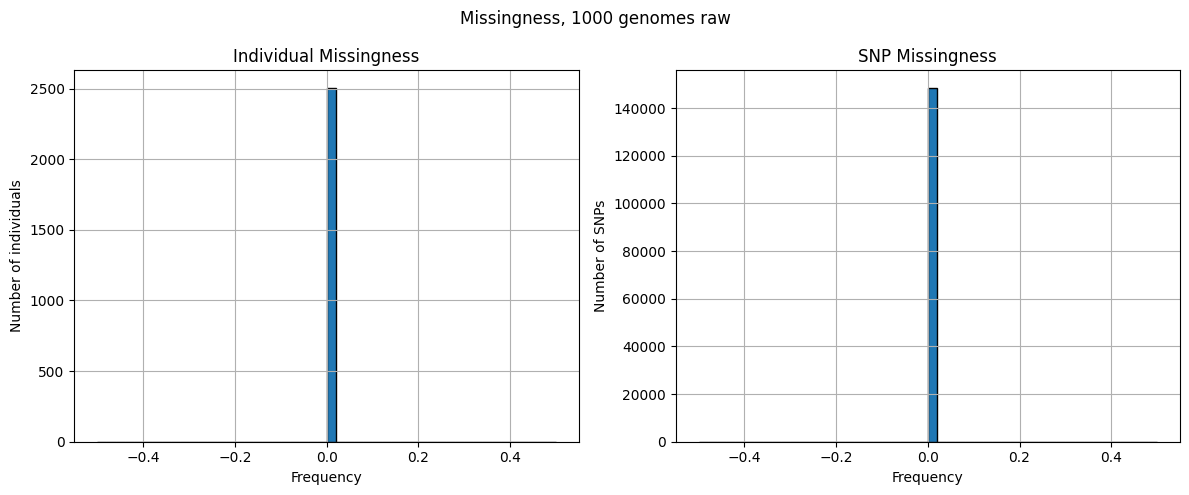

In [4]:
imiss = pd.read_csv('1_qc/missingness.imiss', delim_whitespace=True)
lmiss = pd.read_csv('1_qc/missingness.lmiss', delim_whitespace=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].hist(imiss['F_MISS'], bins=50, edgecolor='black')
axs[0].set_title('Individual Missingness')
axs[0].set_xlabel('Frequency')
axs[0].set_ylabel('Number of individuals')
axs[0].grid(True)

axs[1].hist(lmiss['F_MISS'], bins=50, edgecolor='black')
axs[1].set_title('SNP Missingness')
axs[1].set_xlabel('Frequency')
axs[1].set_ylabel('Number of SNPs')
axs[1].grid(True)

plt.suptitle('Missingness, 1000 genomes raw')
plt.tight_layout()
plt.show()

## Pre-merging quality control

/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/3892847842.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  kaz_fin_maf = pd.read_csv('7_final_exclude/final_qc/kazakh_maf.frq', delim_whitespace=True)
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/3892847842.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  db_1000_gen_fin_maf = pd.read_csv('7_final_exclude/final_qc/1000_gen_maf.frq', delim_whitespace=True)


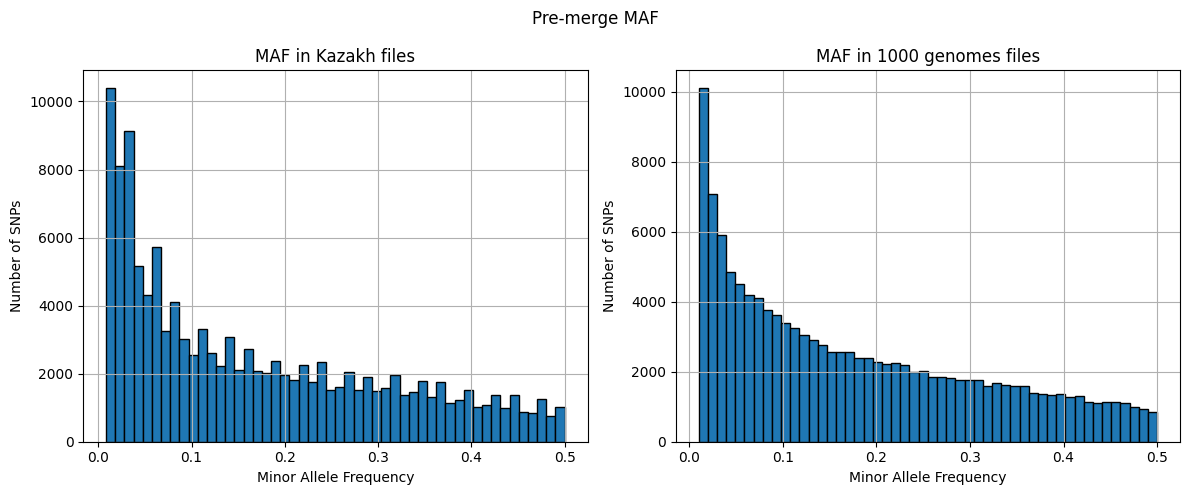

In [5]:
kaz_fin_maf = pd.read_csv('7_final_exclude/final_qc/kazakh_maf.frq', delim_whitespace=True)
db_1000_gen_fin_maf = pd.read_csv('7_final_exclude/final_qc/1000_gen_maf.frq', delim_whitespace=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].hist(kaz_fin_maf['MAF'], bins=50, edgecolor='black')
axs[0].set_title('MAF in Kazakh files')
axs[0].set_xlabel('Minor Allele Frequency')
axs[0].set_ylabel('Number of SNPs')
axs[0].grid(True)

axs[1].hist(db_1000_gen_fin_maf['MAF'], bins=50, edgecolor='black')
axs[1].set_title('MAF in 1000 genomes files')
axs[1].set_xlabel('Minor Allele Frequency')
axs[1].set_ylabel('Number of SNPs')
axs[1].grid(True)

plt.suptitle('Pre-merge MAF')
plt.tight_layout()
plt.show()

/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/4110807538.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  kaz_fin_imiss = pd.read_csv('7_final_exclude/final_qc/kazakh_miss.imiss', delim_whitespace=True)
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/4110807538.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  kaz_fin_lmiss = pd.read_csv('7_final_exclude/final_qc/kazakh_miss.lmiss', delim_whitespace=True)
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_26103/4110807538.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  db_1000_gen_fin_imiss = pd.read_csv('7_final_exclude/final_qc/1000_gen_miss.imiss', delim_whitespace=True)
/var/folders/vz/rlwzk

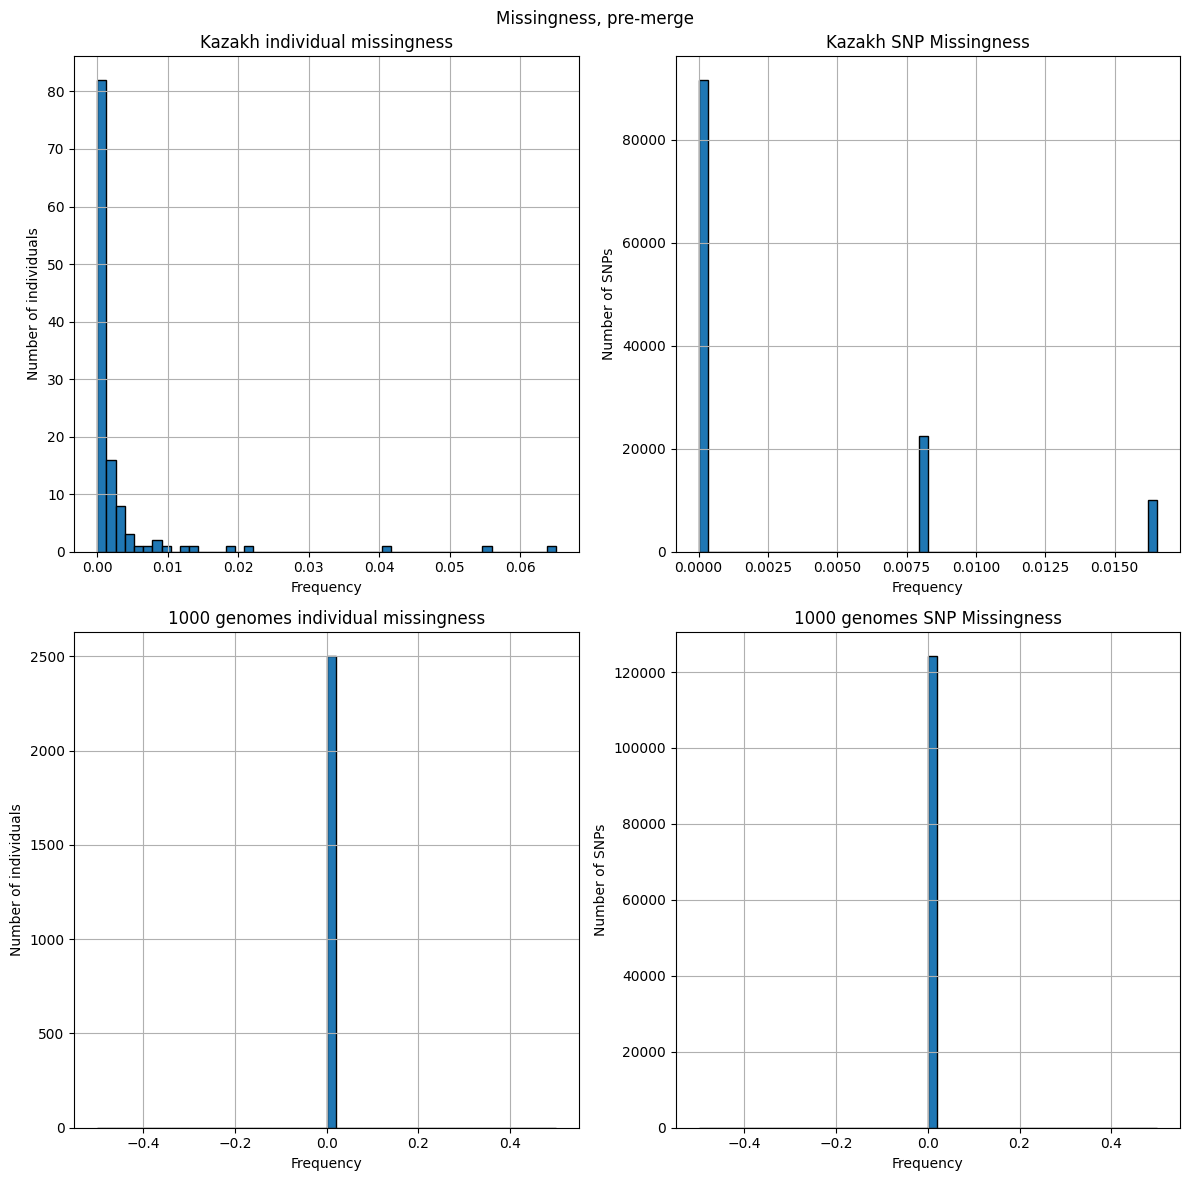

In [6]:
kaz_fin_imiss = pd.read_csv('7_final_exclude/final_qc/kazakh_miss.imiss', delim_whitespace=True)
kaz_fin_lmiss = pd.read_csv('7_final_exclude/final_qc/kazakh_miss.lmiss', delim_whitespace=True)
db_1000_gen_fin_imiss = pd.read_csv('7_final_exclude/final_qc/1000_gen_miss.imiss', delim_whitespace=True)
db_1000_gen_fin_lmiss = pd.read_csv('7_final_exclude/final_qc/1000_gen_miss.lmiss', delim_whitespace=True)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs[0,0].hist(kaz_fin_imiss['F_MISS'], bins=50, edgecolor='black')
axs[0,0].set_title('Kazakh individual missingness')
axs[0,0].set_xlabel('Frequency')
axs[0,0].set_ylabel('Number of individuals')
axs[0,0].grid(True)

axs[0,1].hist(kaz_fin_lmiss['F_MISS'], bins=50, edgecolor='black')
axs[0,1].set_title('Kazakh SNP Missingness')
axs[0,1].set_xlabel('Frequency')
axs[0,1].set_ylabel('Number of SNPs')
axs[0,1].grid(True)

axs[1,0].hist(db_1000_gen_fin_imiss['F_MISS'], bins=50, edgecolor='black')
axs[1,0].set_title('1000 genomes individual missingness')
axs[1,0].set_xlabel('Frequency')
axs[1,0].set_ylabel('Number of individuals')
axs[1,0].grid(True)

axs[1,1].hist(db_1000_gen_fin_lmiss['F_MISS'], bins=50, edgecolor='black')
axs[1,1].set_title('1000 genomes SNP Missingness')
axs[1,1].set_xlabel('Frequency')
axs[1,1].set_ylabel('Number of SNPs')
axs[1,1].grid(True)

plt.suptitle('Missingness, pre-merge')
plt.tight_layout()
plt.show()

## PCA

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_49495/2533076282.py:1: SyntaxWarning: invalid escape sequence '\s'
  pca_data = pd.read_csv('10_pca/pca_res.eigenvec', sep='\s+', header=None)


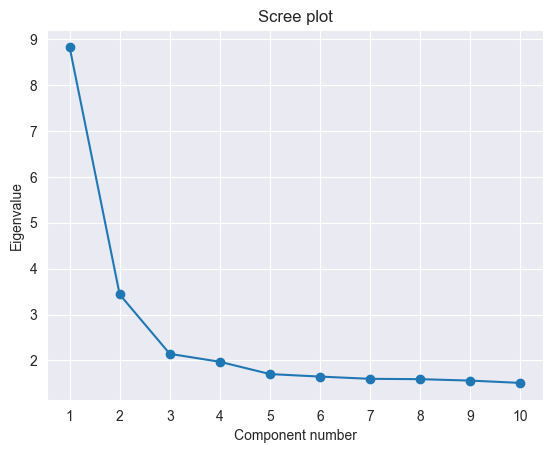

In [4]:
pca_data = pd.read_csv('10_pca/pca_res.eigenvec', sep='\s+', header=None)
pca_data.columns = ['FID', 'IID'] + [f'PC{i}' for i in range(1, pca_data.shape[1] - 1)]
evals = pd.read_csv('10_pca/pca_res.eigenval', header=None)[0]

plt.plot(range(1,11), evals[:10], marker='o')
plt.xticks(range(1, 11))
plt.title('Scree plot')
plt.xlabel('Component number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

In [5]:
total_var = evals.sum()
var_explained = (evals / total_var) * 100

print("Variance explained by each PC:")
for i, var in enumerate(var_explained, 1):
    print(f"PC{i}: {var:.1f}%")

Variance explained by each PC:
PC1: 34.0%
PC2: 13.2%
PC3: 8.2%
PC4: 7.6%
PC5: 6.6%
PC6: 6.3%
PC7: 6.2%
PC8: 6.1%
PC9: 6.0%
PC10: 5.8%


In [6]:
print("\nCumulative variance explained:")
cum_var = np.cumsum(var_explained)
for i, var in enumerate(cum_var, 1):
    print(f"PC1 to PC{i}: {var:.1f}%")


Cumulative variance explained:
PC1 to PC1: 34.0%
PC1 to PC2: 47.2%
PC1 to PC3: 55.4%
PC1 to PC4: 63.0%
PC1 to PC5: 69.6%
PC1 to PC6: 75.9%
PC1 to PC7: 82.1%
PC1 to PC8: 88.2%
PC1 to PC9: 94.2%
PC1 to PC10: 100.0%


In [7]:
pop_info = {}

for file in glob.glob('8_subset/*.tsv'):
    df = pd.read_csv(file, sep='\t', header=None)
    for row in df.itertuples(index=False):
        sample = str(row[0]).strip()
        population = str(row[4]).strip()
        pop_info[sample] = population

pca_data['Population'] = pca_data['IID'].map(
    lambda x: pop_info.get(x, 'Kazakh' if str(x).startswith('WE') else 'Unknown')
)

def get_distinct_colors(n, lightness=0.4, saturation=0.8):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [mcolors.to_hex(colorsys.hls_to_rgb(h, lightness, saturation)) for h in hues]

populations = sorted(pca_data['Population'].unique())
color_list = get_distinct_colors(len(populations))
color_dict = dict(zip(populations, color_list))

for pop in populations:
    count = len(pca_data[pca_data['Population'] == pop])
    print(f'{pop}: {count} samples')

Bengali: 10 samples
British: 10 samples
Dai Chinese: 10 samples
Finnish: 10 samples
Gujarati: 10 samples
Han Chinese: 10 samples
Iberian: 10 samples
Japanese: 10 samples
Kazakh: 121 samples
Kinh Vietnamese: 10 samples
Punjabi: 10 samples
Tamil: 10 samples
Toscani: 10 samples


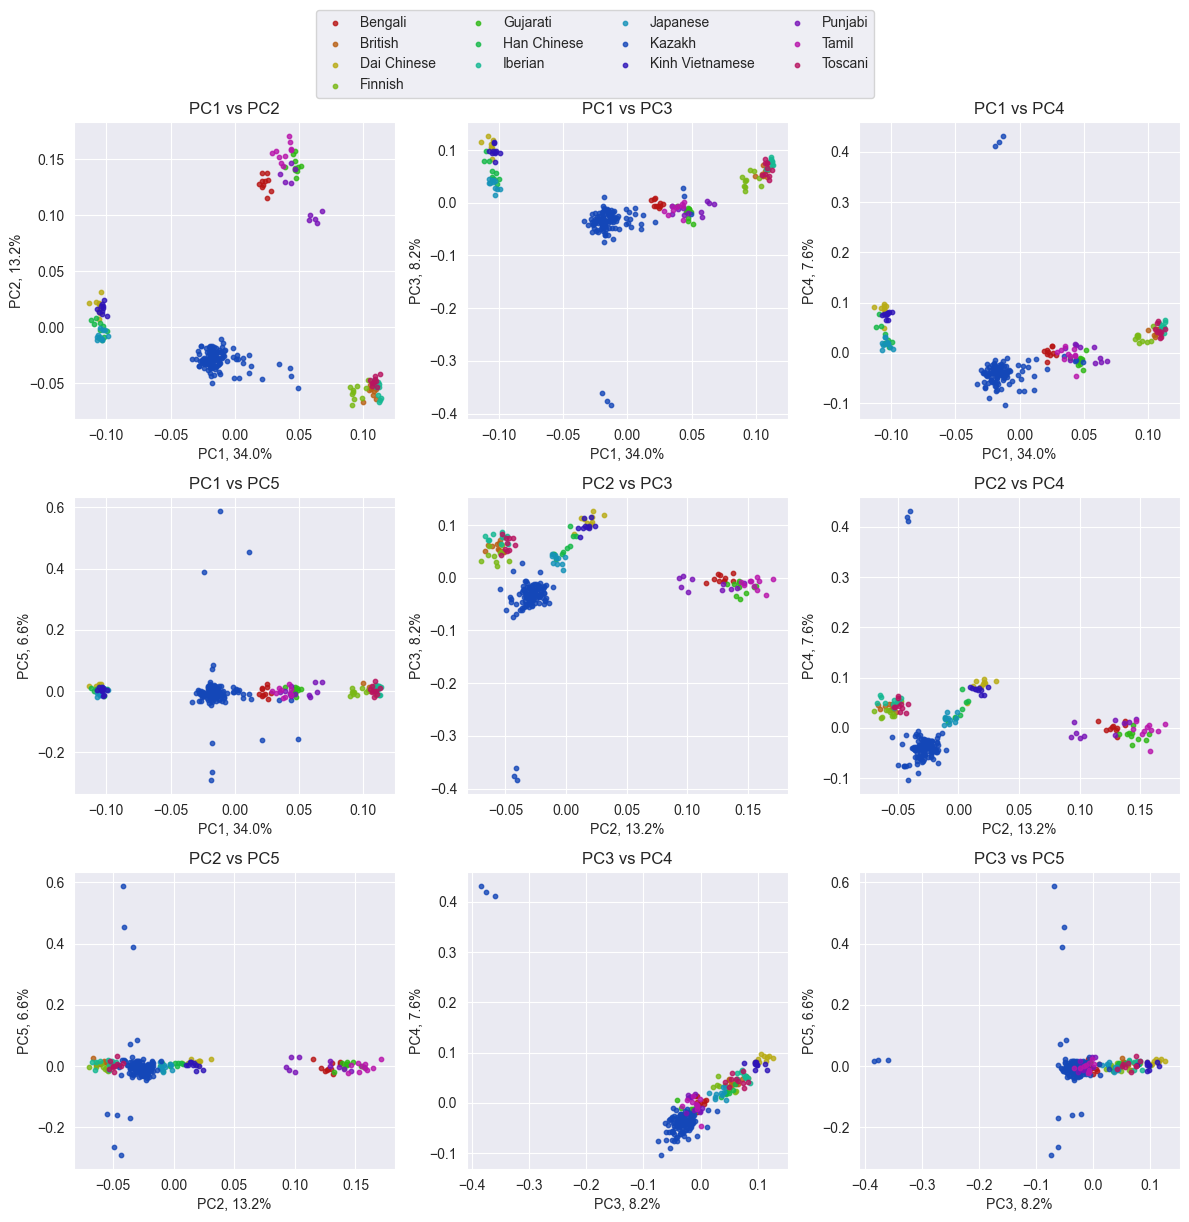

In [8]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
plot_combinations = [(1, 2), (1, 3), (1, 4), (1,5), (2,3), (2,4), (2,5), (3,4), (3,5)]

for ax, (x_pc, y_pc) in zip(axs.flatten(), plot_combinations):
    for pop in sorted(pca_data['Population'].unique()):
        subset = pca_data[pca_data['Population'] == pop]
        ax.scatter(
            subset[f'PC{x_pc}'], subset[f'PC{y_pc}'],
            label=pop, color= color_dict[pop], s=10, alpha=0.8)

    ax.set_xlabel(f'PC{x_pc}, {var_explained[(x_pc-1)]:.1f}%')
    ax.set_ylabel(f'PC{y_pc}, {var_explained[(y_pc-1)]:.1f}%')
    ax.set_title(f'PC{x_pc} vs PC{y_pc}')
    ax.grid(True)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
plt.show()

In [9]:
kz = pca_data[pca_data['Population'] == 'Kazakh']

center = kz[[f'PC{i}' for i in range(1, 5)]].mean().to_numpy()

pca_data['dist_from_kz_center'] = pca_data[[f'PC{i}' for i in range(1, 5)]].apply(
    lambda row: euclidean(row, center), axis=1)

kz_dists = pca_data.loc[pca_data['Population'] == 'Kazakh', 'dist_from_kz_center']
z_scores = zscore(kz_dists)

pca_data.loc[pca_data['Population'] == 'Kazakh', 'kz_dist_zscore'] = z_scores
pca_data['kz_outlier'] = pca_data['kz_dist_zscore'].abs() > 2

pca_data.to_csv("pca_with_kz_outliers.csv", index=False)
print(pca_data[pca_data['kz_outlier'] == True][['IID', 'Population', 'dist_from_kz_center', 'kz_dist_zscore']])

       IID Population  dist_from_kz_center  kz_dist_zscore
121  WE002     Kazakh             0.575171        6.331118
190  WE091     Kazakh             0.544064        5.963176
191  WE092     Kazakh             0.561583        6.170395


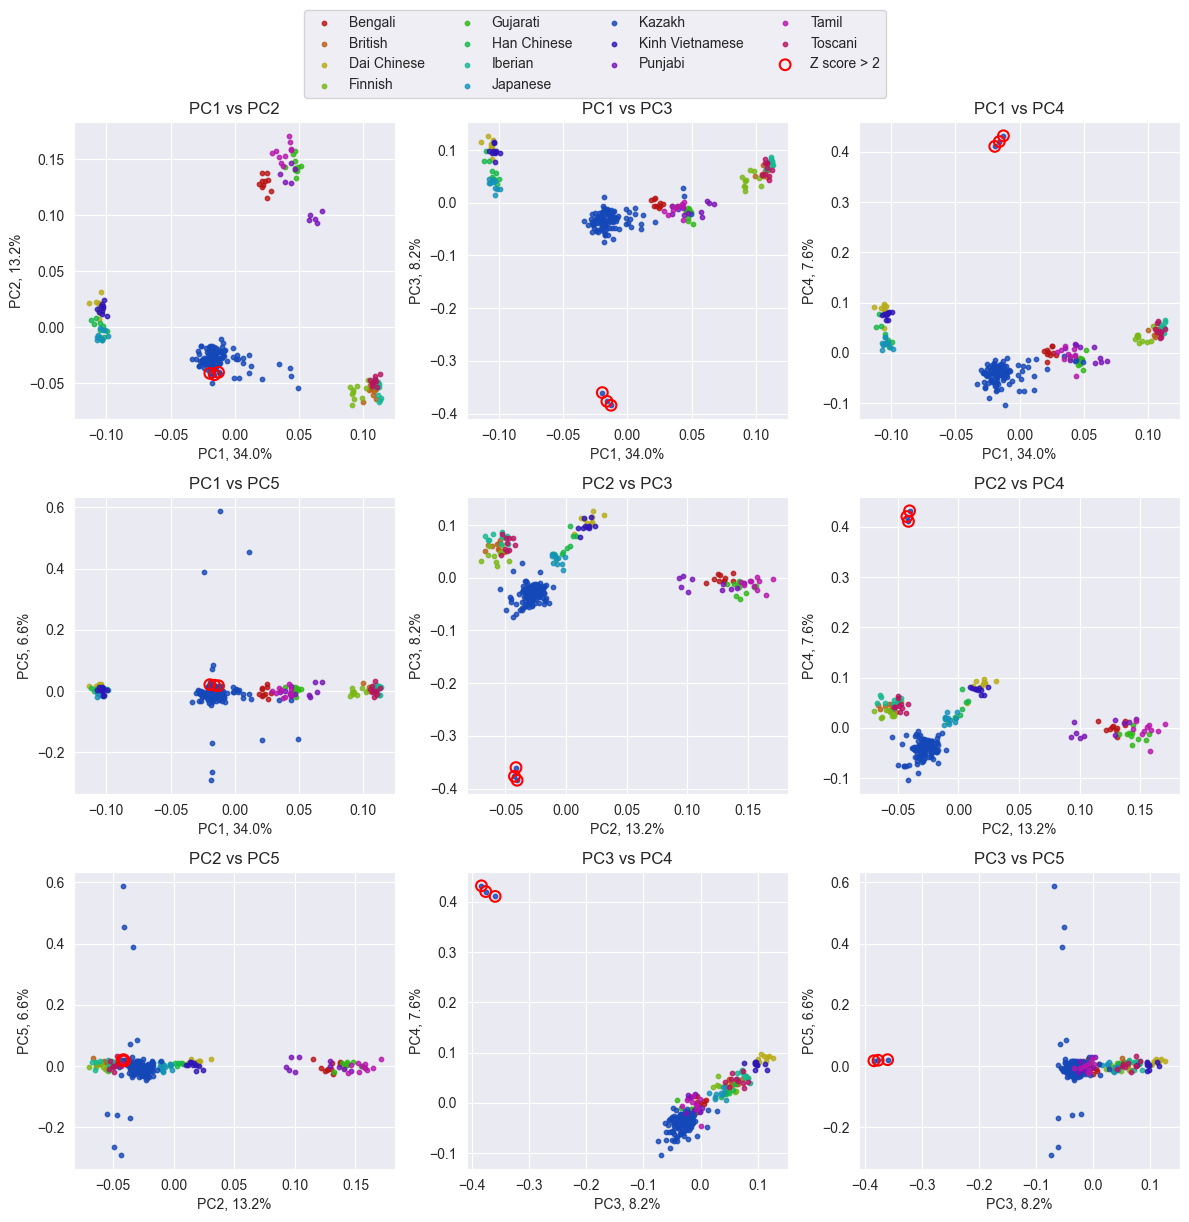

In [10]:
#Highlighting the outliers from Kazakh population

fig, axs = plt.subplots(3, 3, figsize=(12, 12))
plot_combinations = [(1, 2), (1, 3), (1, 4), (1,5), (2,3), (2,4), (2,5), (3,4), (3,5)]
highlighted_ids = ['WE002', 'WE091', 'WE092']

for ax, (x_pc, y_pc) in zip(axs.flatten(), plot_combinations):
    for pop in sorted(pca_data['Population'].unique()):
        subset = pca_data[pca_data['Population'] == pop]
        ax.scatter(
            subset[f'PC{x_pc}'], subset[f'PC{y_pc}'],
            label=pop, color= color_dict[pop], s=10, alpha=0.8)

    highlights = pca_data[pca_data['IID'].isin(highlighted_ids)]
    ax.scatter(
        highlights[f'PC{x_pc}'], highlights[f'PC{y_pc}'],
        facecolors='none', edgecolors='red', s=60, linewidths=1.5,
        label='Z score > 2')

    ax.set_xlabel(f'PC{x_pc}, {var_explained[(x_pc-1)]:.1f}%')
    ax.set_ylabel(f'PC{y_pc}, {var_explained[(y_pc-1)]:.1f}%')
    ax.set_title(f'PC{x_pc} vs PC{y_pc}')
    ax.grid(True)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
plt.show()

## Post outlier removal PCA


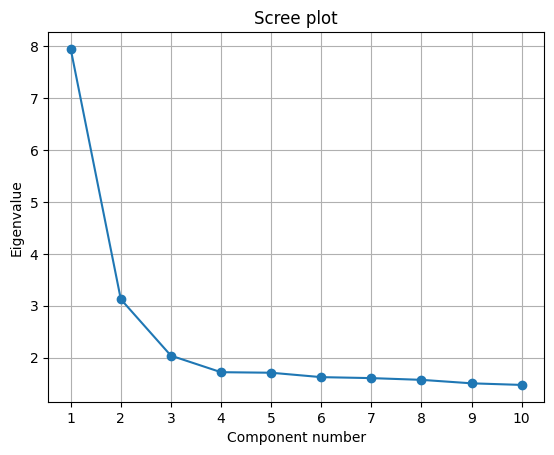

In [4]:
pca_no_outliers = pd.read_csv('13_pruned/pca.eigenvec', sep='\s+', header=None)
pca_no_outliers.columns = ['FID', 'IID'] + [f'PC{i}' for i in range(1, pca_no_outliers.shape[1] - 1)]
evals_no_outliers = pd.read_csv('13_pruned/pca.eigenval', header=None)[0]

plt.plot(range(1,11), evals_no_outliers[:10], marker='o')
plt.xticks(range(1, 11))
plt.title('Scree plot')
plt.xlabel('Component number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

In [6]:
total_var_no_outliers = evals_no_outliers.sum()
var_explained_no_outliers = (evals_no_outliers / total_var_no_outliers) * 100

print("Variance explained by each PC:")
for i, var in enumerate(var_explained_no_outliers, 1):
    print(f"PC{i}: {var:.1f}%")

Variance explained by each PC:
PC1: 32.6%
PC2: 12.8%
PC3: 8.4%
PC4: 7.1%
PC5: 7.0%
PC6: 6.7%
PC7: 6.6%
PC8: 6.5%
PC9: 6.2%
PC10: 6.1%


In [10]:
pop_info_no_outliers = {}

for file in glob.glob('8_subset/*.tsv'):
    df = pd.read_csv(file, sep='\t', header=None)
    for row in df.itertuples(index=False):
        sample = str(row[0]).strip()
        population = str(row[4]).strip()
        pop_info_no_outliers[sample] = population

pca_no_outliers['Population'] = pca_no_outliers['IID'].map(
    lambda x: pop_info_no_outliers.get(x, 'Kazakh' if str(x).startswith('WE') else 'Unknown')
)

def get_distinct_colors(n, lightness=0.4, saturation=0.8):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [mcolors.to_hex(colorsys.hls_to_rgb(h, lightness, saturation)) for h in hues]

populations_no_outliers = sorted(pca_no_outliers['Population'].unique())
color_list = get_distinct_colors(len(populations_no_outliers))
color_dict = dict(zip(populations_no_outliers, color_list))

for pop in populations_no_outliers:
    count = len(pca_no_outliers[pca_no_outliers['Population'] == pop])
    print(f'{pop}: {count} samples')

Bengali: 10 samples
British: 10 samples
Dai Chinese: 10 samples
Finnish: 10 samples
Gujarati: 10 samples
Han Chinese: 10 samples
Iberian: 10 samples
Japanese: 10 samples
Kazakh: 118 samples
Kinh Vietnamese: 10 samples
Punjabi: 10 samples
Tamil: 10 samples
Toscani: 10 samples


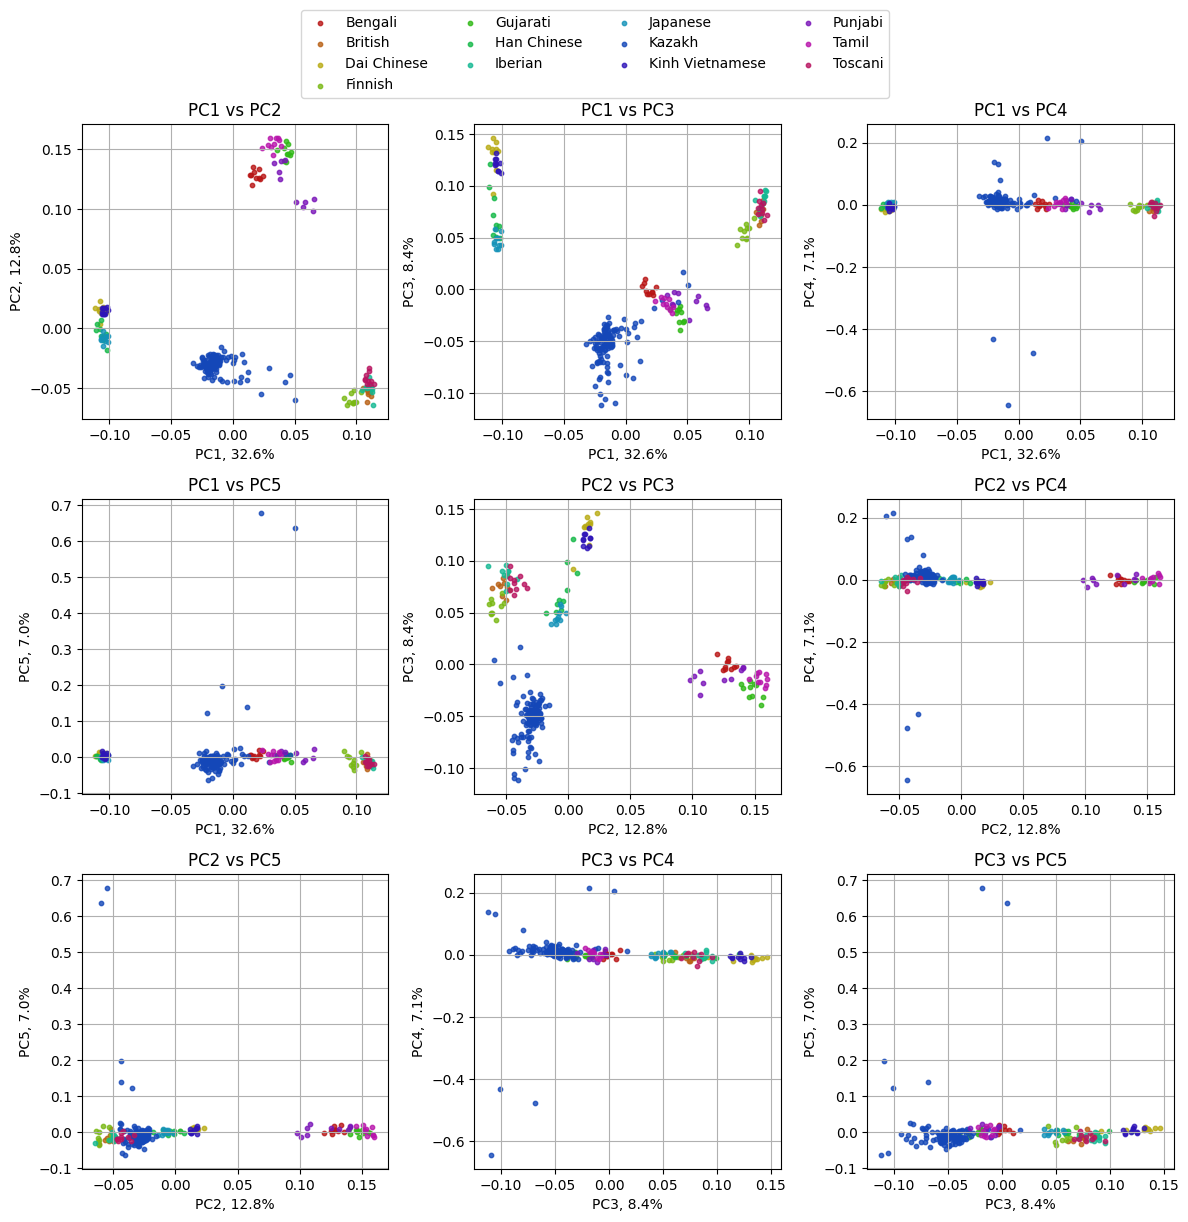

In [11]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
plot_combinations = [(1, 2), (1, 3), (1, 4), (1,5), (2,3), (2,4), (2,5), (3,4), (3,5)]

for ax, (x_pc, y_pc) in zip(axs.flatten(), plot_combinations):
    for pop in sorted(pca_no_outliers['Population'].unique()):
        subset = pca_no_outliers[pca_no_outliers['Population'] == pop]
        ax.scatter(
            subset[f'PC{x_pc}'], subset[f'PC{y_pc}'],
            label=pop, color= color_dict[pop], s=10, alpha=0.8)

    ax.set_xlabel(f'PC{x_pc}, {var_explained_no_outliers[(x_pc-1)]:.1f}%')
    ax.set_ylabel(f'PC{y_pc}, {var_explained_no_outliers[(y_pc-1)]:.1f}%')
    ax.set_title(f'PC{x_pc} vs PC{y_pc}')
    ax.grid(True)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
plt.show()

In [21]:
for pc in ['PC1', 'PC2', 'PC3']:
    pca_no_outliers[pc] = pd.to_numeric(pca_no_outliers[pc], errors='coerce')

fig = px.scatter_3d(
    pca_no_outliers,
    x='PC1', y='PC2', z='PC3',
    color='Population',
    hover_name='IID',
    title='3D PCA Plot (PC1 vs PC2 vs PC3)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(width=900, height=800)
fig.show()


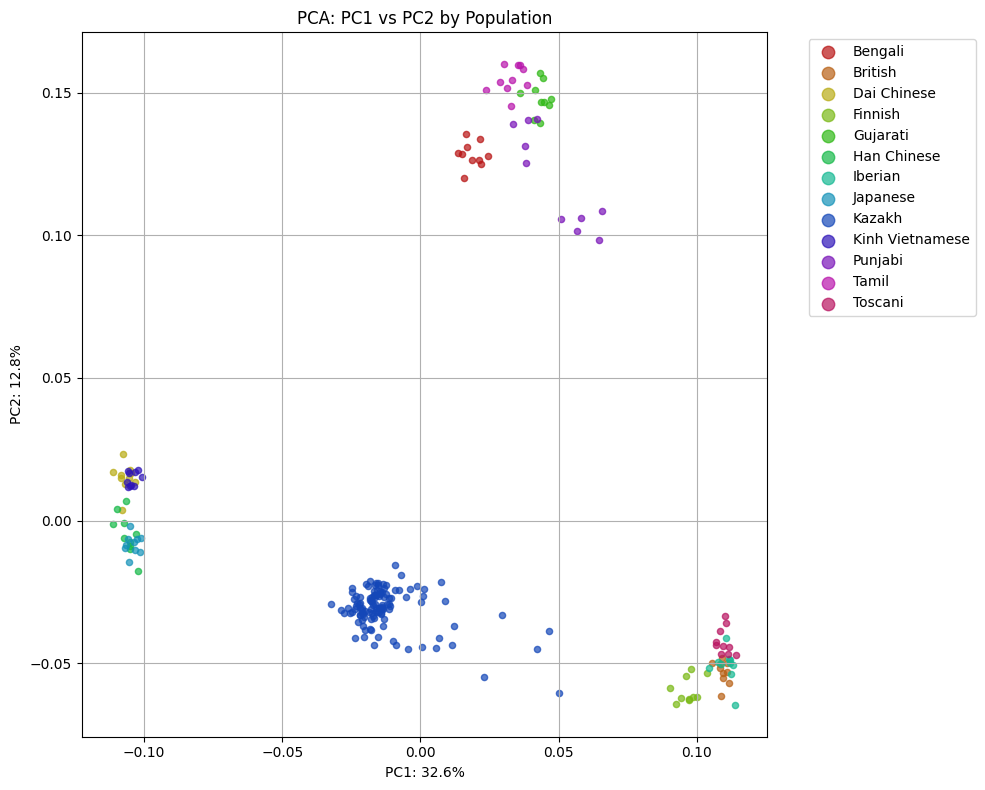

In [13]:
plt.figure(figsize=(10, 8))
for pop in populations_no_outliers:
    subset = pca_no_outliers[pca_no_outliers['Population'] == pop]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, color=color_dict[pop], label=pop, alpha=0.7)

plt.xlabel(f'PC1: {var_explained_no_outliers[0]:.1f}%')
plt.ylabel(f'PC2: {var_explained_no_outliers[1]:.1f}%')
plt.title('PCA: PC1 vs PC2 by Population')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

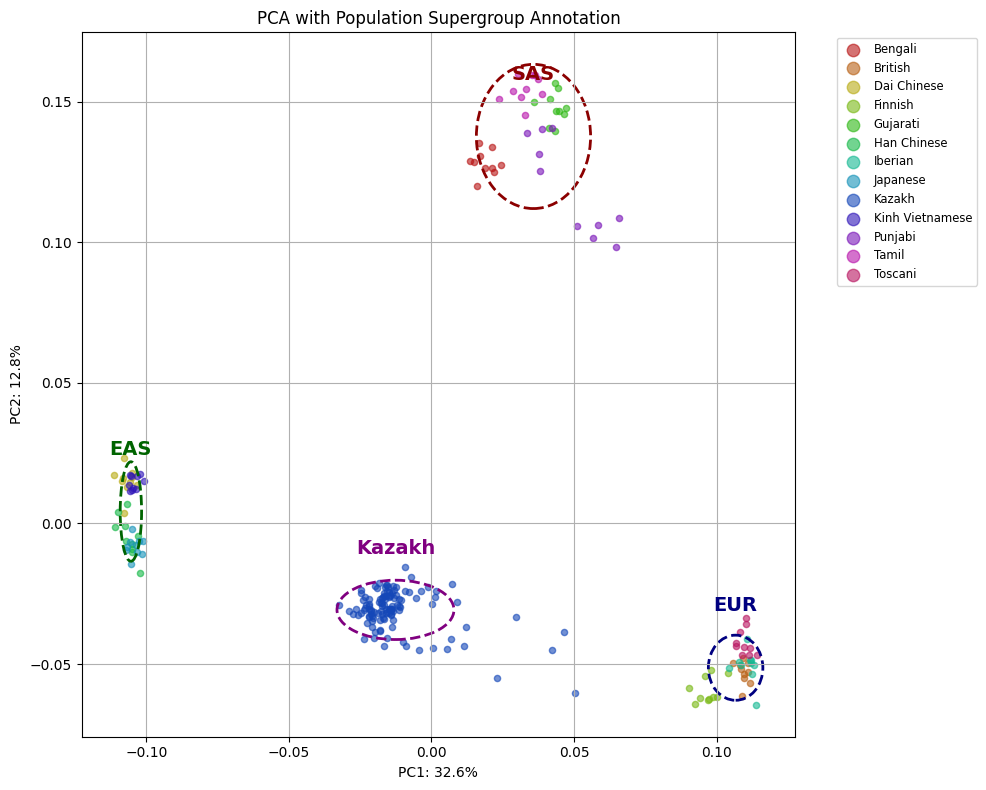

In [15]:
supergroup_map = {
    'EUR': ['Toscani', 'Finnish', 'British', 'Iberian'],
    'SAS': ['Punjabi', 'Gujarati', 'Bengali', 'Tamil'],
    'EAS': ['Han Chinese', 'Kinh Vietnamese', 'Dai Chinese', 'Japanese'],
    'Kazakh': ['Kazakh']}

population_to_supergroup = {pop: sg for sg, pops in supergroup_map.items() for pop in pops}

pca_no_outliers['Supergroup'] = pca_no_outliers['Population'].map(lambda x: population_to_supergroup.get(x, 'Other'))

plt.figure(figsize=(10, 8))

for pop in populations_no_outliers:
    subset = pca_no_outliers[pca_no_outliers['Population'] == pop]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, color=color_dict[pop], label=pop, alpha=0.6)

supergroup_colors = {'EUR': 'navy', 'SAS': 'darkred', 'EAS': 'darkgreen', 'Kazakh': 'purple'}
for sg, group_df in pca_no_outliers.groupby('Supergroup'):
    if sg == 'Other':
        continue
    pc1 = group_df['PC1']
    pc2 = group_df['PC2']

    width = pc1.std() * 3
    height = pc2.std() * 3
    centroid = (pc1.mean(), pc2.mean())
    ellipse = Ellipse(xy=centroid, width=width, height=height, edgecolor=supergroup_colors[sg],
                      facecolor='none', lw=2, linestyle='--')
    plt.gca().add_patch(ellipse)

    plt.text(centroid[0], centroid[1] + 0.02, sg, fontsize=14, weight='bold',
             color=supergroup_colors[sg], ha='center')

plt.xlabel(f'PC1: {var_explained_no_outliers[0]:.1f}%')
plt.ylabel(f'PC2: {var_explained_no_outliers[1]:.1f}%')
plt.title('PCA with Population Supergroup Annotation')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

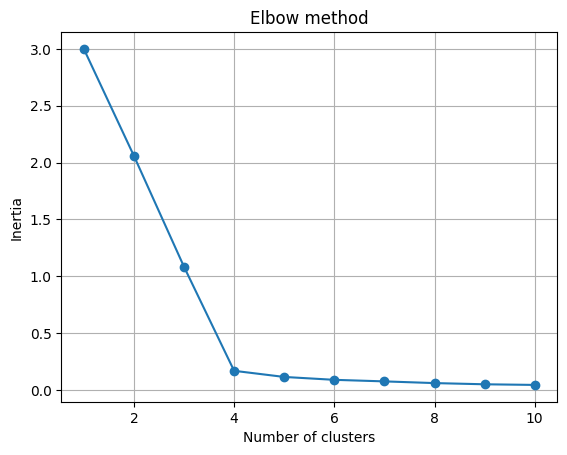

In [16]:
inertias = []
X = pca_no_outliers.iloc[:, 2:5]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

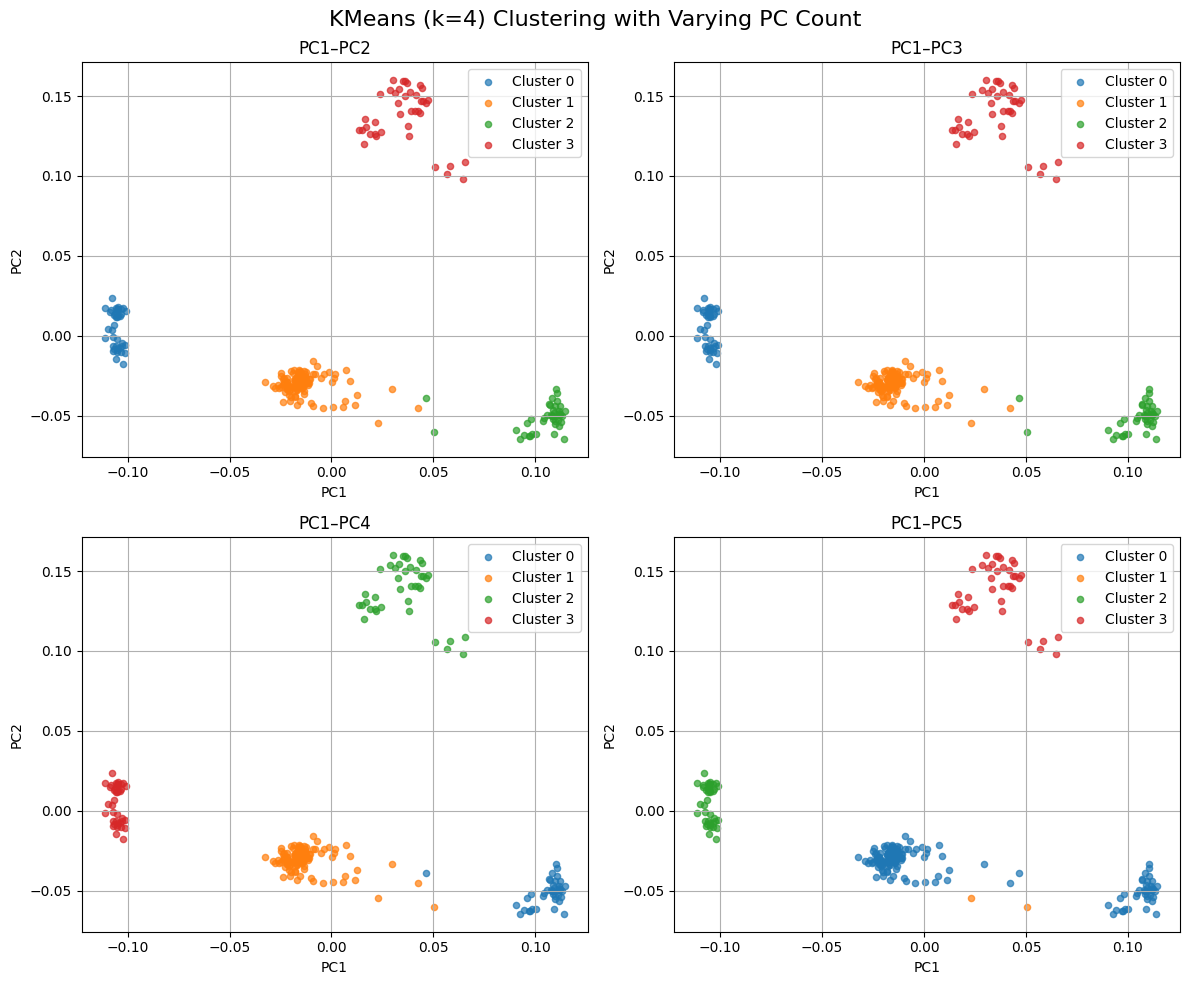

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, i in enumerate(range(2, 6)):
    pcs = [f'PC{j}' for j in range(1, i+1)]
    X = pca_no_outliers[pcs]
    kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    ax = axes[idx]

    for c in range(4):
        subset = pca_no_outliers[labels == c]
        ax.scatter(subset['PC1'], subset['PC2'], s=20, label=f'Cluster {c}', alpha=0.7)

    ax.set_title(f'PC1–PC{i}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True)
    ax.legend()

plt.suptitle('KMeans (k=4) Clustering with Varying PC Count', fontsize=16)
plt.tight_layout()
plt.show()

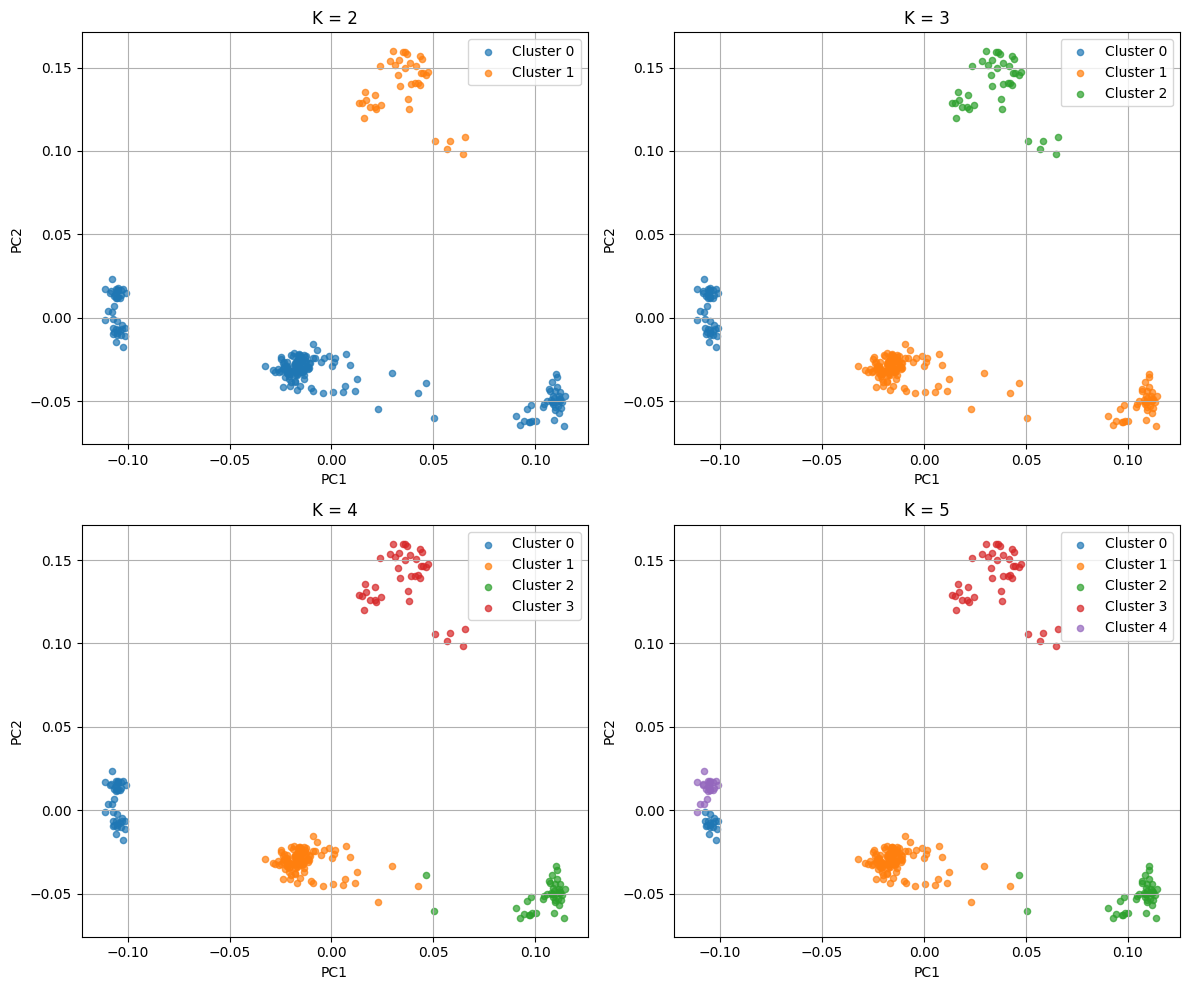

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, i in enumerate(range(2, 6)):
    pcs = [f'PC{j}' for j in range(1, 4)]
    X = pca_no_outliers[pcs]

    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    ax = axes[idx]
    for c in range(i):
        subset = pca_no_outliers[labels == c]
        ax.scatter(subset['PC1'], subset['PC2'], s=20, label=f'Cluster {c}', alpha=0.7)

    ax.set_title(f'K = {i}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

Kazakh cluster: 1
Kazakh → Cluster 0: 0.1754
Kazakh → Cluster 2: 0.1722
Kazakh → Cluster 3: 0.1797


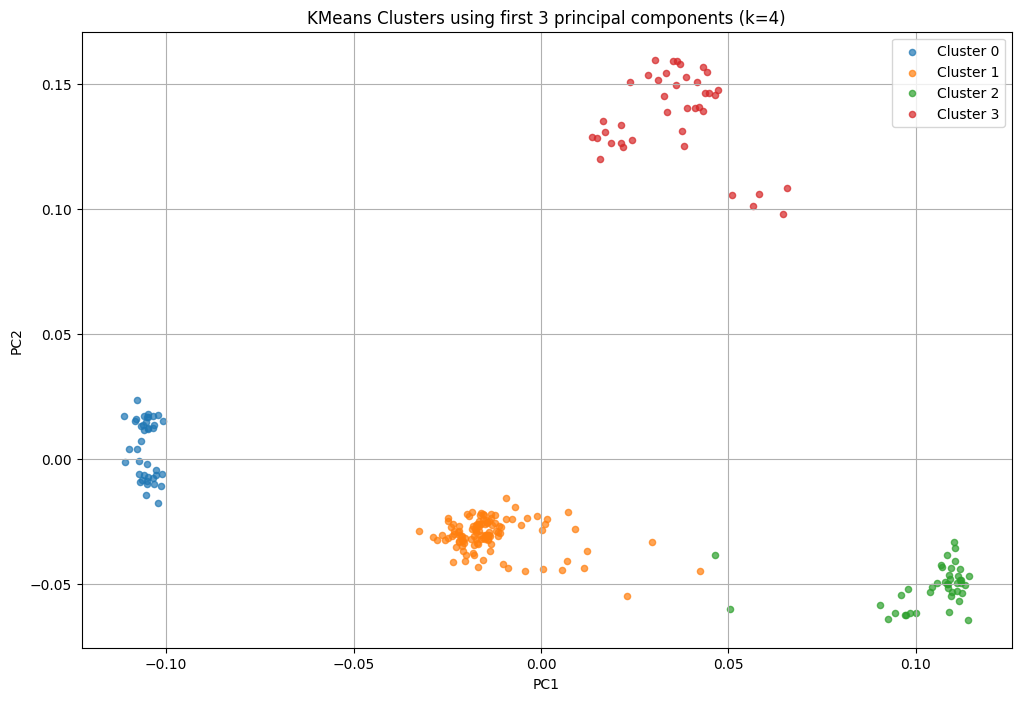

In [22]:
pcs = ['PC1', 'PC2', 'PC3']
X = pca_no_outliers[pcs]

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
pca_no_outliers['Cluster'] = labels

kazakh_counts = (pca_no_outliers[pca_no_outliers['Population'] == 'Kazakh'].groupby('Cluster').size())
kazakh_cluster = kazakh_counts.idxmax()

centroids = pca_no_outliers.groupby('Cluster')[pcs].mean()
kazakh_center = centroids.loc[kazakh_cluster]
distances = {}

for cluster_id in centroids.index:
    if cluster_id == kazakh_cluster:
        continue
    other_center = centroids.loc[cluster_id]
    dist = euclidean(kazakh_center, other_center)
    distances[f"Kazakh → Cluster {cluster_id}"] = dist

print(f"Kazakh cluster: {kazakh_cluster}")
for label, dist in distances.items():
    print(f"{label}: {dist:.4f}")

plt.figure(figsize=(12, 8))
for c in range(4):
    subset = pca_no_outliers[pca_no_outliers['Cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, label=f'Cluster {c}', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.title('KMeans Clusters using first 3 principal components (k=4)')
plt.show()


In [20]:
fig = go.Figure()

for cluster_id in centroids.index:
    subset = pca_no_outliers[pca_no_outliers['Cluster'] == cluster_id]
    fig.add_trace(go.Scatter3d(
        x=subset['PC1'], y=subset['PC2'], z=subset['PC3'],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=3),
        opacity=0.6))

for cluster_id, row in centroids.iterrows():
    fig.add_trace(go.Scatter3d(
        x=[row['PC1']], y=[row['PC2']], z=[row['PC3']],
        mode='markers+text',
        name=f'Centroid {cluster_id}',
        marker=dict(size=10, color='black' if cluster_id == kazakh_cluster else 'red'),
        text=[f'C{cluster_id}'],
        textposition='top center'))

for cluster_id, other_center in centroids.iterrows():
    if cluster_id == kazakh_cluster:
        continue
    fig.add_trace(go.Scatter3d(
        x=[kazakh_center['PC1'], other_center['PC1']],
        y=[kazakh_center['PC2'], other_center['PC2']],
        z=[kazakh_center['PC3'], other_center['PC3']],
        mode='lines',
        name=f'Distance to C{cluster_id}',
        line=dict(color='gray', width=2, dash='dash')))

fig.update_layout(title=f'3D PCA with Cluster Centroids (Kazakh = Cluster {kazakh_cluster})',scene=dict(xaxis_title='PC1',yaxis_title='PC2', zaxis_title='PC3'),width=900,height=900)
fig.show()
